# CookieYes: Product & Marketing Analytics (Full Execution Notebook)
**Objective:** Identify onboarding bottlenecks, analyze retention, and optimize marketing Return on Ad Spend (ROAS) to maximize Monthly Recurring Revenue (MRR).
This notebook contains the complete end-to-end code, from initial EDA to the final publication-ready visualizations.

### 1. Setup & Initialization

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import json
from google.colab import drive

# Set a premium, modern style for all charts
sns.set_theme(style="whitegrid", rc={
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.edgecolor": "#E0E0E0",
    "font.family": "sans-serif"
})

# Display settings for Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

import warnings
warnings.filterwarnings('ignore')

### 2. Data Ingestion & Exploratory Data Analysis (EDA)
**Goal:** Understand the shape of the data, identify missing values, and locate data integrity issues before building metrics.

In [6]:
# Step 1: Mount the Google Drive to access the raw datasets
drive.mount('/content/drive')

# Step 2: Define the primary file path for the assignment data
# Note for reviewers: Update this path if running locally or from a different drive location
path = '/content/drive/MyDrive/CookieYes/assignment_dataset/'

# Step 3: Load the structured datasets (CSV and TSV) into pandas DataFrames for initial inspection
# We are starting with the smaller, structured files before tackling the larger JSON/Log files
accounts_df = pd.read_csv(path + 'accounts.csv')
subscriptions_df = pd.read_csv(path + 'subscriptions.csv')
invoices_df = pd.read_csv(path + 'invoices.tsv', sep='\t')

# Step 4: Extract and print the schema (column names) for each dataset
# This output will be used to map out the Entity-Relationship (ER) logic and identify join keys
print("--- ACCOUNTS SCHEMA ---")
print(accounts_df.columns.tolist())

print("\n--- SUBSCRIPTIONS SCHEMA ---")
print(subscriptions_df.columns.tolist())

print("\n--- INVOICES SCHEMA ---")
print(invoices_df.columns.tolist())

Mounted at /content/drive
--- ACCOUNTS SCHEMA ---
['account_id', 'signup_date', 'utm_source', 'utm_campaign', 'ref', 'account_type', '_sig_parsed']

--- SUBSCRIPTIONS SCHEMA ---
['subscription_id', 'account_id', 'plan_name', 'plan_type', 'billing_cycle_start_date', 'billing_cycle_end_date', 'status', 'is_trial', 'trial_start_date', 'trial_end_date', 'conversion_flag', 'renewal_count', 'cancel_reason', 'plan_start_date']

--- INVOICES SCHEMA ---
['invoice_id', 'subscription_id', 'account_id', 'invoice_date', 'amount', 'currency', 'status', 'tax_amount']


In [7]:
# Inspecting the unstructured data

# Step 1: Inspect the Ad Performance JSON
print("--- AD PERFORMANCE PREVIEW ---")
try:
    with open(path + 'ad_performance.json', 'r') as f:
        ad_data = json.load(f)

        # Check if it's a list of records or a nested dictionary
        if isinstance(ad_data, list):
            print(f"Format: List containing {len(ad_data)} records.")
            print(f"Keys in the first record: {list(ad_data[0].keys())}")
        elif isinstance(ad_data, dict):
            print(f"Format: Dictionary.")
            print(f"Top-level keys: {list(ad_data.keys())}")
except Exception as e:
    print(f"Error reading JSON: {e}")

# Step 2: Inspect the Mixpanel Events Log safely
# We only read the first 3 lines to understand the format without loading 27MB into memory
print("\n--- MIXPANEL LOG PREVIEW (First 3 lines) ---")
try:
    with open(path + 'mixpanel_events.log', 'r') as f:
        for i in range(3):
            line = f.readline().strip()
            print(f"Line {i+1}: {line}")
except Exception as e:
    print(f"Error reading Log: {e}")

--- AD PERFORMANCE PREVIEW ---
Format: List containing 912 records.
Keys in the first record: ['campaign_id', 'campaign_name', 'date', 'impressions', 'clicks', 'cost', 'conversions']

--- MIXPANEL LOG PREVIEW (First 3 lines) ---
Line 1: {"event_id": "evt_1c7b7768663f", "event_time": "2025-07-21T07:21:00", "event_name": "website_scanned", "account_id": "acc_264a22a679cd", "subscription_id": "sub_e69ac9463c02", "properties": {"platform": "wordpress_plugin", "source": "referral", "acquisition_campaign": "Campaign_A", "plan": "ultimate", "billing": "monthly", "scan_id": "869b7317dcae"}}
Line 2: {"event_id": "evt_666775663bb9", "event_time": "2025-10-05T11:04:00", "event_name": "user_returned", "account_id": "acc_fc9915c58c51", "subscription_id": "sub_562689aaf1b1", "properties": {"platform": "web_app", "source": "google", "acquisition_campaign": "Campaign_C", "plan": "free", "billing": "free"}}
Line 3: {"event_id": "evt_4a214cf55962", "event_time": "2025-07-28T15:17:00", "event_name": "use

In [8]:
# Transform the data

# Step 1: Load Ad Performance data into a DataFrame
# Reviewer note: The JSON is a list of records, so pandas handles it natively.

with open(path + 'ad_performance.json', 'r') as f:
    ad_data = json.load(f)
ad_performance_df = pd.DataFrame(ad_data)

# Step 2: Parse and flatten the Mixpanel Events log
# Reviewer note: The log is in JSON-lines format. We parse it line-by-line and flatten the nested 'properties' dictionary for tabular analysis.

events = []
with open(path + 'mixpanel_events.log', 'r') as f:
    for line in f:
        event = json.loads(line.strip())
        # Extract top-level keys
        flat_event = {
            'event_id': event.get('event_id'),
            'event_time': event.get('event_time'),
            'event_name': event.get('event_name'),
            'account_id': event.get('account_id'),
            'subscription_id': event.get('subscription_id')
        }

        # Flatten the nested properties by appending 'prop_' to the column names
        properties = event.get('properties', {})
        for key, value in properties.items():
            flat_event[f"prop_{key}"] = value
        events.append(flat_event)

# Convert the list of flat dictionaries into a pandas DataFrame
mixpanel_df = pd.DataFrame(events)

# Step 3: Standardize Timestamps
# Convert time columns to proper datetime objects for time-series and cohort analysis
mixpanel_df['event_time'] = pd.to_datetime(mixpanel_df['event_time'])
ad_performance_df['date'] = pd.to_datetime(ad_performance_df['date'])

# Let's also do this for our accounts_df from earlier to keep things clean
accounts_df['signup_date'] = pd.to_datetime(accounts_df['signup_date'], format='mixed')

# Step 4: Verify the transformation
print("--- AD PERFORMANCE DATAFRAME ---")
print(ad_performance_df.info())
print("\n--- MIXPANEL EVENTS DATAFRAME ---")
print(mixpanel_df.info())
print("\nUnique Events Tracked in Product:", mixpanel_df['event_name'].unique().tolist())

--- AD PERFORMANCE DATAFRAME ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   campaign_id    912 non-null    object        
 1   campaign_name  912 non-null    object        
 2   date           912 non-null    datetime64[ns]
 3   impressions    912 non-null    int64         
 4   clicks         912 non-null    int64         
 5   cost           912 non-null    float64       
 6   conversions    912 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(2)
memory usage: 50.0+ KB
None

--- MIXPANEL EVENTS DATAFRAME ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84449 entries, 0 to 84448
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   event_id                   84449 non-null 

In [9]:
accounts_df.shape

(3200, 7)

In [10]:
accounts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3200 entries, 0 to 3199
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   account_id    3200 non-null   object        
 1   signup_date   3200 non-null   datetime64[ns]
 2   utm_source    3000 non-null   object        
 3   utm_campaign  3025 non-null   object        
 4   ref           955 non-null    object        
 5   account_type  3200 non-null   object        
 6   _sig_parsed   3200 non-null   object        
dtypes: datetime64[ns](1), object(6)
memory usage: 175.1+ KB


account_id, signup_date, account_type, sig_parsed are all non-nulls.
signup_date=sig_parsed for all. What is sig_parsed column?
signup_date - datetime
Rest of the columns - object
sig_parsed is object, not datetime
utm_source has 200 nulls
utm_campaign has 175 nulls
ref has only 955 values

In [11]:
accounts_df.utm_source.value_counts()

,count
utm_source,
google,527
direct,508
organic,502
email,501
facebook,498
referral,464


google, direct, organic, email, facebook, referral
Diff between organic and direct?
referral has 464 values yet ref column has 955 values. Why?

In [12]:
accounts_df.utm_campaign.value_counts()

,count
utm_campaign,
Campaign_A,806
Campaign_C,553
Campaign_E,526
Campaign_D,458
Campaign_F,351
Campaign_B,281
Campaing_E,27
Campain_C,23


There are 6 campaigns (A-F)
E and C has two versions each due to spelling mistake

In [13]:
accounts_df.account_type.value_counts()

,count
account_type,
normal,2503
agency,594
NORMAL,44
Normal,36
AGENCY,13
Agency,10


Has normal and agency only but has 3 different versions each due to difference in capitalization

In [14]:
accounts_df.ref.value_counts()

,count
ref,
smith.com,10
williams.com,8
miller.com,7
hernandez.com,6
johnson.com,5
...,...
hale.com,1
haynes.com,1
clark-harris.com,1


817 unique referrals. Some of them have referred multiple times, the top being 10 times.

In [16]:
subscriptions_df.shape

(5015, 14)

In [17]:
subscriptions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5015 entries, 0 to 5014
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   subscription_id           5015 non-null   object
 1   account_id                5015 non-null   object
 2   plan_name                 5015 non-null   object
 3   plan_type                 5015 non-null   object
 4   billing_cycle_start_date  5015 non-null   object
 5   billing_cycle_end_date    2590 non-null   object
 6   status                    5015 non-null   object
 7   is_trial                  5015 non-null   bool  
 8   trial_start_date          2292 non-null   object
 9   trial_end_date            2292 non-null   object
 10  conversion_flag           5015 non-null   bool  
 11  renewal_count             5015 non-null   int64 
 12  cancel_reason             1026 non-null   object
 13  plan_start_date           5015 non-null   object
dtypes: bool(2), int64(1), ob

subscription_id, account_id, plan_name, plan_type, billing_cycle_start_date,
status, is_trial, conversion_flag, renewal_count, plan_start_date are all non nulls
billing cycle end_date - 2590 non-null values (There are 2425 free accounts which will have no billing cycle end dates)
is_trial is True for 2292 rows. Hence there are 2292 non-null values for trial_start_date and trial_end_date
cancel_reason - 1026 non-null values. There are 1136 cancellations in total out of which 110 rows have null reasons (reasons hasn't been provided)
billing_cycle_start_date, billing_cycle_end_date, trial_start_date, trial_end_date, plan_start_date - Are all objects, not datetime.
is_trial and conversion_flag - boolean
renewal_count - int
Rest of the columns - object

In [18]:
subscriptions_df.plan_name.value_counts()

,count
plan_name,
free,2341
basic,1294
pro,765
ultimate,461
Free,48
FREE,36
Basic,18
PRO,15
BASIC,13


free, basic, pro, ultimate - Different versions of it (3 each) since difference in capitalization

In [19]:
subscriptions_df.plan_name.str.lower().value_counts()

,count
plan_name,
free,2425
basic,1325
pro,790
ultimate,475


free - 2425, basic - 1325, pro - 790, ultimate - 475

In [20]:
subscriptions_df.account_id.nunique()

3200

200 - Means all the accounts has an entry.

In [21]:
subscriptions_df.plan_type.str.lower().value_counts()

,count
plan_type,
free,2425
monthly,1668
annual,922


In [22]:
subscriptions_df.plan_type.value_counts()

,count
plan_type,
free,2377
monthly,1621
annual,893
Free,26
MONTHLY,26
FREE,22
Monthly,21
Annual,16
ANNUAL,13


3 versions each for the different plan types due to difference in capitalization

In [23]:
subscriptions_df.is_trial.value_counts()

,count
is_trial,
False,2723
True,2292


In [24]:
subscriptions_df.status.value_counts()

,count
status,
active,3879
cancelled,1136


In [25]:
subscriptions_df[(subscriptions_df['status']=='cancelled') & (subscriptions_df['cancel_reason'].isna())]

,subscription_id,account_id,plan_name,plan_type,billing_cycle_start_date,billing_cycle_end_date,status,is_trial,trial_start_date,trial_end_date,conversion_flag,renewal_count,cancel_reason,plan_start_date
59,sub_daf2c3efe66b,acc_e14964f0f00c,free,free,2025-07-26,NaN,cancelled,True,2025-07-26,2025-08-09,False,0,NaN,2025-07-26
80,sub_f4dfc36d234b,acc_bf1042661753,ultimate,annual,2025-07-19,2025-08-07,cancelled,False,NaN,NaN,False,0,NaN,2025-07-19
202,sub_db14848c8c21,acc_7eaa942024be,free,free,2025-07-04,NaN,cancelled,True,2025-07-04,2025-07-18,False,0,NaN,2025-07-04
325,sub_db2ea25eea53,acc_ae07968e581a,free,free,2025/07/07,NaN,cancelled,True,2025-07-07,2025-07-21,False,0,NaN,2025-07-07
367,sub_90ba68cecbcf,acc_c1c8cd462d5f,basic,monthly,2025-07-17,2025-08-30,cancelled,False,NaN,NaN,False,0,NaN,2025-07-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4549,sub_8ccb1307c386,acc_59e4c4845e6f,free,free,2025-06-07,NaN,cancelled,True,2025-06-07,2025-06-21,False,0,NaN,2025-06-07
4617,sub_22ceafe3cdcd,acc_a7aebca0b80c,free,free,2025-10-08,NaN,cancelled,True,2025-10-08,2025-10-22,False,0,NaN,2025-10-08
4629,sub_869c8fd63ea5,acc_90ae9e0fdb3a,basic,annual,2025-10-12,2025-12-08,cancelled,False,NaN,NaN,False,0,NaN,2025-10-12
4643,sub_b0bbe7042c8a,acc_6ae123cfb1c3,free,free,2025/08/18,NaN,cancelled,True,2025-08-18,2025-09-01,False,0,NaN,2025-08-18


In [26]:
subscriptions_df[(subscriptions_df['status']=='cancelled') & (subscriptions_df['cancel_reason'].isna()) & (subscriptions_df['plan_name'].str.lower()!='free')].shape

(52, 14)

52 rows (52 of the cancellations where reason is null are paid accounts)

In [27]:
(subscriptions_df.billing_cycle_start_date<subscriptions_df.billing_cycle_end_date).value_counts()

,count
False,2516
True,2499


In [32]:
subscriptions_df[subscriptions_df['billing_cycle_start_date']=='NaT']

,subscription_id,account_id,plan_name,plan_type,billing_cycle_start_date,billing_cycle_end_date,status,is_trial,trial_start_date,trial_end_date,conversion_flag,renewal_count,cancel_reason,plan_start_date
40,sub_92b44b95d431,acc_21c78ca26dc8,free,free,NaT,NaN,cancelled,True,2025-07-03,2025-07-17,False,0,no_longer_needed,2025-07-03
71,sub_07708b25e1f8,acc_0cdf4c585e01,free,free,NaT,NaN,active,False,NaN,NaN,False,0,NaN,2025-07-21
76,sub_b81037ed16a5,acc_cefa91903649,BASIC,monthly,NaT,2025-08-19,active,True,2025-07-04,2025-07-18,True,3,NaN,2025-07-20
78,sub_72bff6ed5a03,acc_476954a12228,basic,annual,NaT,2026-09-11,active,False,NaN,NaN,False,0,NaN,2025-09-11
92,sub_ec8ade963a89,acc_296492171ae6,basic,monthly,NaT,2025-09-07,cancelled,False,NaN,NaN,False,0,switching_product,2025-08-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4813,sub_248a51336602,acc_cd9046bbe811,basic,annual,NaT,2026-09-07,active,False,NaN,NaN,False,0,NaN,2025-09-07
4937,sub_cb926142f590,acc_7228e39c7567,free,free,NaT,NaN,cancelled,True,2025-07-24,2025-08-07,False,0,no_longer_needed,2025-07-24
4941,sub_94748a9f7cd6,acc_f0cf75fb1d91,free,free,NaT,NaN,active,True,2025-06-14,2025-06-28,False,0,NaN,2025-06-14
4945,sub_453c6b8f10e7,acc_4211f51f4842,free,free,NaT,NaN,active,True,2025-06-26,2025-07-10,False,0,NaN,2025-06-26


In [33]:
subscriptions_df[subscriptions_df['trial_start_date']>subscriptions_df['trial_end_date']]

,subscription_id,account_id,plan_name,plan_type,billing_cycle_start_date,billing_cycle_end_date,status,is_trial,trial_start_date,trial_end_date,conversion_flag,renewal_count,cancel_reason,plan_start_date


In [34]:
subscriptions_df.conversion_flag.value_counts()

,count
conversion_flag,
False,4240
True,775


In [35]:
subscriptions_df.renewal_count.value_counts()

,count
renewal_count,
0,3886
2,418
3,349
1,261
4,97
-1,2
7,1
6,1


3886 rows have zero
Top value is 7
There are 2 entries for -1.

In [36]:
subscriptions_df.cancel_reason.value_counts()

,count
cancel_reason,
too_expensive,223
no_longer_needed,223
missing_features,198
trial_ended,191
switching_product,191


In [37]:
are_dates_equal = (pd.to_datetime(subscriptions_df['billing_cycle_start_date'], format='mixed', errors='coerce') == pd.to_datetime(subscriptions_df['plan_start_date'], format='mixed', errors='coerce'))
display(are_dates_equal.value_counts())

,count
True,4770
False,245


Except the 245 (NaT for billing_cycle_start_date), all dates are same.

In [38]:
invoices_df.shape

(5726, 8)

In [40]:
invoices_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5726 entries, 0 to 5725
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   invoice_id       5726 non-null   object 
 1   subscription_id  5726 non-null   object 
 2   account_id       5726 non-null   object 
 3   invoice_date     5726 non-null   object 
 4   amount           5726 non-null   float64
 5   currency         5726 non-null   object 
 6   status           5726 non-null   object 
 7   tax_amount       5726 non-null   float64
dtypes: float64(2), object(6)
memory usage: 358.0+ KB


In [41]:
invoices_df.subscription_id.nunique()

2569

In [42]:
invoices_df.account_id.nunique()

1881

In [43]:
invoices_df[invoices_df.invoice_date=='NaT']

,invoice_id,subscription_id,account_id,invoice_date,amount,currency,status,tax_amount


In [44]:
invoices_df.describe()

,amount,tax_amount
count,5726.000000,5726.000000
mean,756.651787,68.420358
std,3716.927385,392.153032
min,7.660000,0.000000
25%,9.920000,0.950000
50%,24.720000,1.985000
75%,97.250000,9.060000
max,47117.990000,8057.900000


In [45]:
invoices_df.currency.value_counts()

,count
currency,
USD,2592
EUR,1420
GBP,860
INR,854


In [46]:
invoices_df.status.value_counts()

,count
status,
paid,5347
failed,311
refunded,68


In [47]:
ad_performance_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   campaign_id    912 non-null    object        
 1   campaign_name  912 non-null    object        
 2   date           912 non-null    datetime64[ns]
 3   impressions    912 non-null    int64         
 4   clicks         912 non-null    int64         
 5   cost           912 non-null    float64       
 6   conversions    912 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(2)
memory usage: 50.0+ KB


In [48]:
ad_performance_df.campaign_id.value_counts()

,count
campaign_id,
cmp_campaigna,152
cmp_campaignb,152
cmp_campaignc,152
cmp_campaignd,152
cmp_campaigne,152
cmp_campaignf,152


In [49]:
ad_performance_df.campaign_name.value_counts()

,count
campaign_name,
Campaign_A,152
Campaign_B,152
Campaign_D,152
Campaign_F,152
Campaign_E,150
Campaign_C,149
Campain_C,3
Campaing_E,2


In [50]:
ad_performance_df.date.nunique()

152

In [51]:
ad_performance_df.describe()

,date,impressions,clicks,cost,conversions
count,912,912.000000,912.000000,912.000000,912.000000
mean,2025-08-15 12:00:00,1748.650219,52.690789,110.381382,1.530702
min,2025-06-01 00:00:00,305.000000,4.000000,4.320000,0.000000
25%,2025-07-08 18:00:00,966.500000,25.000000,45.627500,0.000000
50%,2025-08-15 12:00:00,1604.000000,42.000000,82.775000,1.000000
75%,2025-09-22 06:00:00,2416.500000,70.000000,145.310000,2.000000
max,2025-10-30 00:00:00,4498.000000,205.000000,632.060000,10.000000
std,NaN,946.879167,37.428876,94.133122,1.585174


In [52]:
mixpanel_df.shape

(84449, 12)

In [53]:
mixpanel_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84449 entries, 0 to 84448
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   event_id                   84449 non-null  object        
 1   event_time                 84449 non-null  datetime64[ns]
 2   event_name                 84449 non-null  object        
 3   account_id                 84449 non-null  object        
 4   subscription_id            81249 non-null  object        
 5   prop_platform              84449 non-null  object        
 6   prop_source                84449 non-null  object        
 7   prop_acquisition_campaign  84449 non-null  object        
 8   prop_plan                  79661 non-null  object        
 9   prop_billing               79661 non-null  object        
 10  prop_scan_id               49075 non-null  object        
 11  prop_cancel_reason         1136 non-null   object        
dtypes: d

In [54]:
mixpanel_df.account_id.nunique()

3200

All accounts are there

In [55]:
mixpanel_df.subscription_id.nunique()

5015

All subscriptions present

In [57]:
mixpanel_df.subscription_id.isna().sum()

np.int64(3200)

The subscription id won't be created for the first event. Consistent with the number of users.

In [58]:
mixpanel_df.prop_platform.value_counts()

,count
prop_platform,
web_app,46273
wordpress_plugin,38176


In [59]:
mixpanel_df.prop_source.value_counts()

,count
prop_source,
direct,18933
facebook,13500
organic,13375
google,13356
email,13291
referral,11994


In [60]:
mixpanel_df.prop_acquisition_campaign.value_counts()

,count
prop_acquisition_campaign,
Campaign_A,22352
Campaign_C,15595
Campaign_E,14791
Campaign_D,12713
Campaign_F,9706
Campaign_B,7956
Campain_C,740
Campaing_E,596


In [61]:
mixpanel_df.prop_plan.value_counts()

,count
prop_plan,
free,45382
basic,17908
pro,10118
ultimate,6253


In [62]:
mixpanel_df[mixpanel_df.prop_plan.isna()]

,event_id,event_time,event_name,account_id,subscription_id,prop_platform,prop_source,prop_acquisition_campaign,prop_plan,prop_billing,prop_scan_id,prop_cancel_reason
17,evt_55c217654c62,2025-06-10 14:44:00,sign_up,acc_e873127a797d,None,wordpress_plugin,referral,Campaign_C,NaN,NaN,NaN,NaN
19,evt_3724083c60b9,2025-09-13 10:11:00,sign_up,acc_e21ea0d0ea46,None,web_app,google,Campaign_A,NaN,NaN,NaN,NaN
40,evt_40d3335a4662,2025-07-06 18:55:00,sign_up,acc_677fd08d2942,None,wordpress_plugin,direct,Campaign_A,NaN,NaN,NaN,NaN
77,evt_5fffec3a3e57,2025-09-29 10:58:00,sign_up,acc_4e941ba84e85,None,wordpress_plugin,referral,Campaign_C,NaN,NaN,NaN,NaN
100,evt_be3895ef8ae2,2025-06-03 00:50:00,sign_up,acc_9d657dd9979d,None,web_app,facebook,Campaign_E,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
84362,evt_147e62a9bf00,2025-07-23 03:26:00,scan_completed,acc_91043f98529d,sub_655130194e3f,web_app,direct,Campaign_C,NaN,NaN,NaN,NaN
84403,evt_a0317fa573ba,2025-07-19 16:45:00,sign_up,acc_92c45a59f308,None,wordpress_plugin,direct,Campaign_C,NaN,NaN,NaN,NaN
84406,evt_fbce6ef9fb91,2025-08-04 14:07:00,scan_completed,acc_f394423acb20,sub_09eb12a1558b,web_app,email,Campaign_E,NaN,NaN,NaN,NaN
84414,evt_d07f6b09823d,2025-09-20 12:38:00,scan_completed,acc_14538f8a6b88,sub_b3550687797b,wordpress_plugin,organic,Campaign_A,NaN,NaN,NaN,NaN


4788 Nan values

In [63]:
mixpanel_df.prop_scan_id.isna().sum()

np.int64(35374)

In [75]:
mixpanel_df.prop_cancel_reason.value_counts().reset_index().rename(columns={'index': 'cancel_reason', 'prop_cancel_reason': 'count'})

,count,count
0,too_expensive,223
1,no_longer_needed,223
2,missing_features,198
3,switching_product,191
4,trial_ended,191
5,unknown,110


In [65]:
mixpanel_df.describe()

,event_time
count,84449
mean,2025-08-21 02:52:23.362976512
min,2025-06-01 00:18:00
25%,2025-07-23 11:30:00
50%,2025-08-23 05:37:00
75%,2025-09-20 06:23:00
max,2026-01-16 01:28:00


### 3. Data Cleaning & Preprocessing
**Goal:** Fix the issues identified in EDA. Deduplicate events, impute missing dates, and normalize all revenue to USD.

In [66]:
# ==========================================
# 1. CLEANING ACCOUNTS_DF
# ==========================================
accounts_df = accounts_df.drop(columns=['_sig_parsed'], errors='ignore')
accounts_df['account_type'] = accounts_df['account_type'].str.lower().str.strip()

if accounts_df['utm_campaign'].dtype == 'O':
    accounts_df['utm_campaign'] = accounts_df['utm_campaign'].str.title().str.strip()
    accounts_df['utm_campaign'] = accounts_df['utm_campaign'].replace({
        r'(?i).*camp.*c.*': 'Campaign_C',
        r'(?i).*camp.*e.*': 'Campaign_E'
    }, regex=True)

# ==========================================
# 2. CLEANING SUBSCRIPTIONS_DF
# ==========================================
subscriptions_df['plan_name'] = subscriptions_df['plan_name'].str.lower().str.strip()
subscriptions_df['plan_type'] = subscriptions_df['plan_type'].str.lower().str.strip()
subscriptions_df['renewal_count'] = subscriptions_df['renewal_count'].replace(-1, 0)

date_cols = ['billing_cycle_start_date', 'billing_cycle_end_date', 'trial_start_date', 'trial_end_date', 'plan_start_date']
for col in date_cols:
    subscriptions_df[col] = subscriptions_df[col].replace('NaT', pd.NA)
    subscriptions_df[col] = pd.to_datetime(subscriptions_df[col], format='mixed', errors='coerce')

# Impute missing billing cycle start dates
subscriptions_df['billing_cycle_start_date'] = subscriptions_df['billing_cycle_start_date'].fillna(subscriptions_df['plan_start_date'])

# ==========================================
# 3. CLEANING INVOICES_DF
# ==========================================
invoices_df['invoice_date'] = invoices_df['invoice_date'].replace('NaT', pd.NA)
invoices_df['invoice_date'] = pd.to_datetime(invoices_df['invoice_date'], format='mixed', errors='coerce')

# ==========================================
# 4. CLEANING AD_PERFORMANCE_DF
# ==========================================
if ad_performance_df['campaign_name'].dtype == 'O':
    ad_performance_df['campaign_name'] = ad_performance_df['campaign_name'].str.title().str.strip()
    ad_performance_df['campaign_name'] = ad_performance_df['campaign_name'].replace({
        r'(?i).*camp.*c.*': 'Campaign_C',
        r'(?i).*camp.*e.*': 'Campaign_E'
    }, regex=True)

# ==========================================
# 5. CLEANING MIXPANEL_DF
# ==========================================
if mixpanel_df['prop_acquisition_campaign'].dtype == 'O':
    mixpanel_df['prop_acquisition_campaign'] = mixpanel_df['prop_acquisition_campaign'].str.title().str.strip()
    mixpanel_df['prop_acquisition_campaign'] = mixpanel_df['prop_acquisition_campaign'].replace({
        r'(?i).*camp.*c.*': 'Campaign_C',
        r'(?i).*camp.*e.*': 'Campaign_E'
    }, regex=True)

print("--- All Dataframes Cleaned & Standardized ---")
print("Ad Campaigns Cleaned:\n", ad_performance_df['campaign_name'].value_counts())
print("\nMixpanel Campaigns Cleaned:\n", mixpanel_df['prop_acquisition_campaign'].value_counts().head(6))

--- All Dataframes Cleaned & Standardized ---
Ad Campaigns Cleaned:
 campaign_name
Campaign_A    152
Campaign_B    152
Campaign_C    152
Campaign_D    152
Campaign_E    152
Campaign_F    152
Name: count, dtype: int64

Mixpanel Campaigns Cleaned:
 prop_acquisition_campaign
Campaign_A    22352
Campaign_C    16335
Campaign_E    15387
Campaign_D    12713
Campaign_F     9706
Campaign_B     7956
Name: count, dtype: int64


### 4. Phase 1: The Activation Funnel
**Question:** Where do users get stuck during onboarding?

*Methodology:* Because product usage is non-linear (e.g., auto-subscriptions via the WordPress plugin), I used a chronological-agnostic pivot table (`aggfunc='min'`) to capture absolute milestone completion rates rather than strict sequential steps.

In [67]:
# Step 1: Define the core activation funnel steps
# Based on manual product testing, script installation precedes the website scan.
funnel_events = ['sign_up', 'script_installed', 'banner_activated']

# Step 2: Filter the Mixpanel data for just these core events
funnel_df = mixpanel_df[mixpanel_df['event_name'].isin(funnel_events)].copy()

# Step 3: Pivot the data to map the journey of each unique account
user_funnel = funnel_df.pivot_table(
    index=['account_id', 'prop_platform'],
    columns='event_name',
    values='event_time',
    aggfunc='min'
).reset_index()

# Step 4: Create boolean flags indicating if a user completed a specific step
for step in funnel_events:
    if step in user_funnel.columns:
        user_funnel[f'did_{step}'] = user_funnel[step].notna()
    else:
        user_funnel[f'did_{step}'] = False

# Step 5: Aggregate the overall funnel numbers
overall_funnel = user_funnel[[f'did_{step}' for step in funnel_events]].sum()

# Step 6: Create a readable summary table with drop-off percentages
funnel_summary = pd.DataFrame({'Users': overall_funnel})
funnel_summary['%_of_Signups'] = (funnel_summary['Users'] / funnel_summary['Users'].iloc[0] * 100).round(2)
funnel_summary['Step_to_Step_Conversion_%'] = (funnel_summary['Users'] / funnel_summary['Users'].shift(1) * 100).round(2)
funnel_summary.loc['did_sign_up', 'Step_to_Step_Conversion_%'] = 100.0

# Step 7: Segment the funnel by platform (Web App vs. WordPress)
platform_funnel = user_funnel.groupby('prop_platform')[[f'did_{step}' for step in funnel_events]].sum()
platform_funnel['Activation_Rate_%'] = (platform_funnel['did_banner_activated'] / platform_funnel['did_sign_up'] * 100).round(2)

# Print outputs for the true narrative
print("--- OVERALL FUNNEL SUMMARY ---")
print(funnel_summary)

print("\n--- PLATFORM COMPARISON ---")
print(platform_funnel[['did_sign_up', 'did_script_installed', 'did_banner_activated', 'Activation_Rate_%']])

--- OVERALL FUNNEL SUMMARY ---
                      Users  %_of_Signups  Step_to_Step_Conversion_%
event_name                                                          
did_sign_up            3200        100.00                     100.00
did_script_installed   2563         80.09                      80.09
did_banner_activated   2191         68.47                      85.49

--- PLATFORM COMPARISON ---
event_name        did_sign_up  did_script_installed  did_banner_activated  Activation_Rate_%
prop_platform                                                                               
web_app                  1761                  1395                  1205              68.43
wordpress_plugin         1439                  1168                   986              68.52


### 5. Phase 2: Retention & Revenue Mechanics (The Leaky Bucket)
**Question:** How does acquisition source impact user quality, and is our MRR sustainable?

*Methodology:* I merged event telemetry with subscription billing to calculate true churn rates and map the trajectory of our Monthly Recurring Revenue. Here, we investigate the "Scan-to-Buy" paradox: users paying for a one-time audit but failing to activate the recurring core product, leading to immediate churn.

In [68]:
# Step 1: Merge the datasets
# We bring together acquisition (accounts), product behavior (funnel), and revenue (subscriptions)
merged_df = accounts_df.merge(user_funnel, on='account_id', how='left')

sub_cols = ['account_id', 'plan_name', 'plan_type', 'is_trial', 'conversion_flag', 'status', 'billing_cycle_start_date', 'renewal_count']
full_journey_df = merged_df.merge(subscriptions_df[sub_cols], on='account_id', how='left')

# Step 2: Isolate the Trial Users for Conversion Analysis
# We only want to look at users who had the opportunity to convert from a trial
trial_users = full_journey_df[full_journey_df['is_trial'] == True]

# Step 3: Calculate Overall Trial-to-Paid Conversion Rate
overall_conversion = trial_users['conversion_flag'].mean() * 100

# Step 4: Calculate Conversion Rate Segmented by Platform
platform_conversion = trial_users.groupby('prop_platform')['conversion_flag'].mean() * 100

# Step 5: Calculate Conversion Rate based on Product Activation
# Does getting the banner live actually make them more likely to buy?
activation_conversion = trial_users.groupby('did_banner_activated')['conversion_flag'].agg(['mean', 'count'])
activation_conversion['mean'] = activation_conversion['mean'] * 100
activation_conversion = activation_conversion.rename(columns={'mean': 'Conversion_Rate_%', 'count': 'Total_Trial_Users'})

# Step 6: Output the insights
print("--- OVERALL TRIAL-TO-PAID CONVERSION ---")
print(f"{overall_conversion:.2f}%\n")

print("--- CONVERSION BY PLATFORM ---")
print(platform_conversion.round(2).astype(str) + '%')

print("\n--- CONVERSION IMPACT OF ACTIVATION ---")
print(activation_conversion.round(2))

--- OVERALL TRIAL-TO-PAID CONVERSION ---
33.81%

--- CONVERSION BY PLATFORM ---
prop_platform
web_app             33.12%
wordpress_plugin    34.68%
Name: conversion_flag, dtype: object

--- CONVERSION IMPACT OF ACTIVATION ---
                      Conversion_Rate_%  Total_Trial_Users
did_banner_activated                                      
False                             33.80                716
True                              33.82               1576


In [69]:
# Step 1: Filter for only paying customers (those who ever had a paid plan)
# We exclude 'free' plans to focus purely on monetization retention
paid_users = full_journey_df[(full_journey_df['plan_name'] != 'free') & (full_journey_df['plan_name'].notna())].copy()

# Step 2: Calculate overall Churn Rate (Cancelled / Total Paid)
total_paid = len(paid_users)
churned = len(paid_users[paid_users['status'] == 'cancelled'])
overall_churn_rate = (churned / total_paid) * 100

# Step 3: Does Activation prevent Churn?
# Calculate churn rate specifically for activated vs. non-activated paid users
churn_by_activation = paid_users.groupby('did_banner_activated')['status'].apply(
    lambda x: (x == 'cancelled').mean() * 100
).rename('Churn_Rate_%').reset_index()

# Add average renewal counts to see the actual financial impact
ltv_by_activation = paid_users.groupby('did_banner_activated')['renewal_count'].mean().reset_index()
churn_analysis = pd.merge(churn_by_activation, ltv_by_activation, on='did_banner_activated')
churn_analysis = churn_analysis.rename(columns={'renewal_count': 'Avg_Billing_Cycles_Completed'})

# Step 4: Quality of Acquisition Source (Marketing Efficiency)
# Are some marketing sources bringing in high volumes of users who churn immediately?
source_quality = paid_users.groupby('utm_source').agg(
    Total_Paid_Users=('account_id', 'count'),
    Avg_Billing_Cycles=('renewal_count', 'mean')
)
source_churn = paid_users.groupby('utm_source')['status'].apply(
    lambda x: (x == 'cancelled').mean() * 100
).rename('Churn_Rate_%')

source_quality = source_quality.join(source_churn).sort_values('Avg_Billing_Cycles', ascending=False)

# Step 5: Outputs
print(f"--- OVERALL PAID CHURN RATE --- \n{overall_churn_rate:.2f}%\n")
print("--- DOES ACTIVATION PREVENT CHURN? ---")
print(churn_analysis.round(2).to_string(index=False))
print("\n--- RETENTION BY ACQUISITION SOURCE ---")
print(source_quality.round(2))

--- OVERALL PAID CHURN RATE --- 
20.42%

--- DOES ACTIVATION PREVENT CHURN? ---
 did_banner_activated  Churn_Rate_%  Avg_Billing_Cycles_Completed
                False         20.37                          0.92
                 True         20.44                          1.00

--- RETENTION BY ACQUISITION SOURCE ---
            Total_Paid_Users  Avg_Billing_Cycles  Churn_Rate_%
utm_source                                                    
referral                 362                1.06         20.72
direct                   433                0.98         21.25
facebook                 429                0.98         20.05
google                   398                0.97         22.11
organic                  401                0.95         19.70
email                    397                0.94         19.90


### 6. Phase 3: Marketing Efficiency & ROAS
**Question:** Which campaigns drive profitable growth vs. empty volume?

*Methodology:* To calculate true Return on Ad Spend (ROAS), I normalized all international invoices to USD, subtracted tax amounts to isolate Net Revenue, and mapped it against Total Ad Spend per campaign.

In [70]:
# Step 1: Currency Normalization & Net Revenue Calculation
# Define approximate exchange rates to USD
exchange_rates = {
    'USD': 1.0,
    'EUR': 1.10,
    'GBP': 1.30,
    'INR': 0.012
}

# Apply exchange rates
invoices_df['exchange_rate'] = invoices_df['currency'].map(exchange_rates)

# Calculate true Net Revenue in USD (Gross Amount - Tax)
invoices_df['net_amount_usd'] = (invoices_df['amount'] - invoices_df['tax_amount']) * invoices_df['exchange_rate']

# Step 2: Calculate actual realized Net Revenue per account from PAID invoices
# This explicitly excludes 'refunded' and 'failed' statuses
revenue_per_account = invoices_df[invoices_df['status'] == 'paid'].groupby('account_id')['net_amount_usd'].sum().reset_index(name='total_revenue_usd')

# Step 3: Tie revenue and paid status back to the acquisition campaign
account_revenue = accounts_df.merge(revenue_per_account, on='account_id', how='left').fillna({'total_revenue_usd': 0})
paid_account_ids = paid_users['account_id'].unique()
account_revenue['is_paid_customer'] = account_revenue['account_id'].isin(paid_account_ids)

# Step 4: Aggregate metrics by Campaign
campaign_metrics = account_revenue.groupby('utm_campaign').agg(
    Total_Signups=('account_id', 'count'),
    Paid_Customers=('is_paid_customer', 'sum'),
    Net_Revenue_USD=('total_revenue_usd', 'sum')
).reset_index()

# Step 5: Aggregate Ad Spend by Campaign
ad_spend = ad_performance_df.groupby('campaign_name').agg(
    Total_Ad_Spend_USD=('cost', 'sum'),
    Total_Clicks=('clicks', 'sum')
).reset_index()

# Step 6: Merge Ad data with Revenue data
roas_df = ad_spend.merge(campaign_metrics, left_on='campaign_name', right_on='utm_campaign', how='inner')

# Step 7: Calculate Marketing KPIs
# CAC = Total Ad Spend / Number of Paid Customers Acquired
roas_df['CAC_per_Paid_Customer'] = roas_df['Total_Ad_Spend_USD'] / roas_df['Paid_Customers']

# ROAS = (Net Revenue / Total Ad Spend) * 100
roas_df['ROAS_%'] = (roas_df['Net_Revenue_USD'] / roas_df['Total_Ad_Spend_USD']) * 100

# Add the intuitive stakeholder metric
roas_df['Revenue_Per_$1_Spent'] = roas_df['Net_Revenue_USD'] / roas_df['Total_Ad_Spend_USD']

# Format and sort by profitability
output_cols = ['campaign_name', 'Total_Ad_Spend_USD', 'Net_Revenue_USD', 'CAC_per_Paid_Customer', 'ROAS_%', 'Revenue_Per_$1_Spent']
roas_final = roas_df[output_cols].sort_values('ROAS_%', ascending=False)

# Format the new column to look like currency for the final printout
roas_final['Revenue_Per_$1_Spent'] = roas_final['Revenue_Per_$1_Spent'].apply(lambda x: f"${x:.2f}")

print("--- MARKETING CAMPAIGN ROI & ROAS ---")
print(roas_final.round(2).to_string(index=False))

--- MARKETING CAMPAIGN ROI & ROAS ---
campaign_name  Total_Ad_Spend_USD  Net_Revenue_USD  CAC_per_Paid_Customer  ROAS_% Revenue_Per_$1_Spent
   Campaign_F            11435.58         37023.98                  49.94  323.76                $3.24
   Campaign_B             8506.01         27310.93                  44.53  321.08                $3.21
   Campaign_A            26726.91         72888.62                  55.34  272.72                $2.73
   Campaign_D            14442.82         38117.87                  53.29  263.92                $2.64
   Campaign_E            18403.57         42197.48                  59.75  229.29                $2.29
   Campaign_C            21152.93         46675.82                  66.94  220.66                $2.21


Setting up the MRR Trend DataFrame
This block will extract the month from the invoice dates, sum the net revenue, and format the dates so that Looker Studio can automatically detect them as a time-series dimension.

In [71]:
# Extract the month/year from the invoice date
invoices_df['invoice_month'] = invoices_df['invoice_date'].dt.to_period('M')

# Sum the net revenue for paid invoices by month
mrr_trend = invoices_df[invoices_df['status'] == 'paid'].groupby('invoice_month')['net_amount_usd'].sum().reset_index()

# Convert the period back to a standard timestamp (the 1st of each month)
# Looker Studio handles standard datetimes much better than pandas periods
mrr_trend['invoice_month'] = mrr_trend['invoice_month'].dt.to_timestamp()

print("--- MRR TREND PREVIEW ---")
print(mrr_trend)

--- MRR TREND PREVIEW ---
  invoice_month  net_amount_usd
0    2025-06-01     11672.67520
1    2025-07-01     62213.81512
2    2025-08-01     74711.34320
3    2025-09-01     68809.51064
4    2025-10-01     64432.88704


### Exporting the Datasets for Looker Studio

In [72]:
import os

# Create an export directory in your Drive to keep things organized
# (This uses the 'path' variable you defined in Phase 1)
export_path = path + 'dashboard_exports/'
if not os.path.exists(export_path):
    os.makedirs(export_path)

# 1. Export Funnel Data
funnel_summary.to_csv(export_path + 'funnel_data.csv', index=True)

# 2. Export Retention/Quality Data
source_quality.to_csv(export_path + 'retention_data.csv', index=True)

# 3. Export Campaign Performance (ROAS)
roas_final.to_csv(export_path + 'campaign_performance.csv', index=False)

# 4. Export MRR Trend over time
mrr_trend.to_csv(export_path + 'mrr_trend.csv', index=False)

print("--- EXPORT COMPLETE ---")
print(f"4 CSV files successfully saved to: {export_path}")

--- EXPORT COMPLETE ---
4 CSV files successfully saved to: /content/drive/MyDrive/CookieYes/assignment_dataset/dashboard_exports/


# Visualizations

## 1. Setup & The Activation Funnel

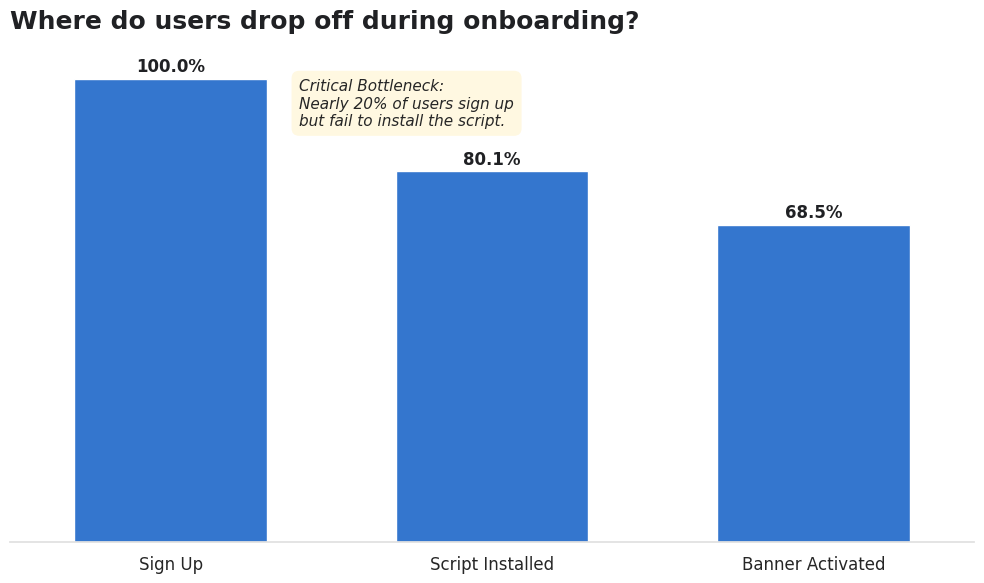

In [74]:
# Set a premium, modern style for all charts
sns.set_theme(style="whitegrid", rc={
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.edgecolor": "#E0E0E0",
    "font.family": "sans-serif"
})

# --- CHART 1: ACTIVATION FUNNEL ---
fig, ax = plt.subplots(figsize=(10, 6))
bars = sns.barplot(
    x=funnel_summary.index,
    y=funnel_summary['%_of_Signups'],
    color="#1A73E8", # Clean tech blue
    ax=ax,
    width=0.6
)

# Add the percentages directly on top of the bars
for p in bars.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9), textcoords='offset points',
                fontweight='bold', color='#202124')

# Clean up axes and titles
ax.set_title("Where do users drop off during onboarding?", fontsize=18, fontweight='bold', color="#202124", pad=20, loc='left')
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_yticks([]) # Hide the y-axis entirely for a cleaner look
ax.set_xticklabels(['Sign Up', 'Script Installed', 'Banner Activated'], fontsize=12)

# Add the Insight Annotation Box
ax.text(0.4, 90, "Critical Bottleneck:\nNearly 20% of users sign up\nbut fail to install the script.",
        fontsize=11, style='italic', bbox=dict(facecolor='#FFF8E1', edgecolor='none', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

## 2. The MRR Trend (The Leaky Bucket)

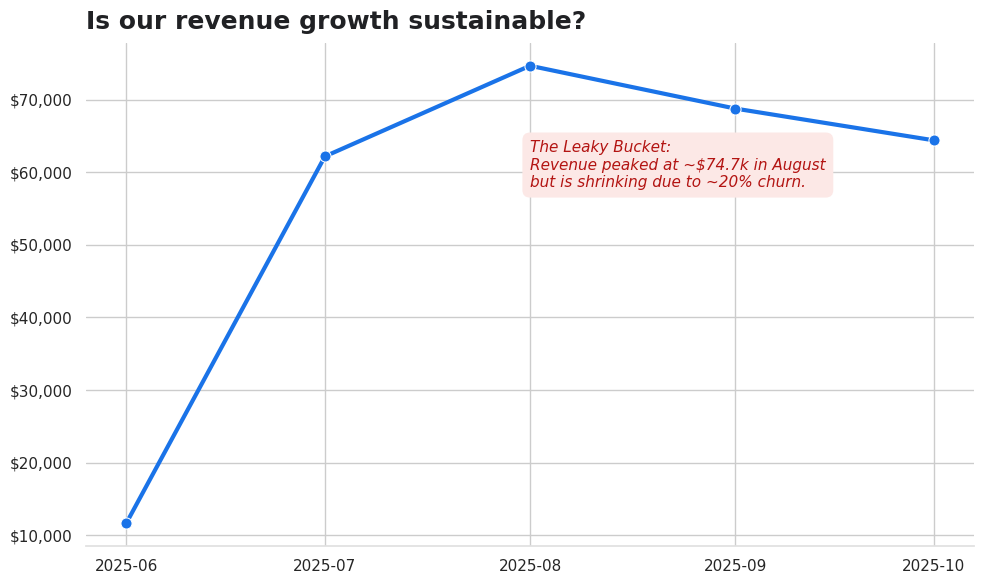

In [80]:
# --- CHART 2: MRR TREND ---
import matplotlib.dates as mdates
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the line with markers
sns.lineplot(
  data=mrr_trend,
  x='invoice_month',
  y='net_amount_usd',
  marker='o',
  markersize=8,
  color="#1A73E8",
  linewidth=3,
  ax=ax
)

# Format the Y-axis as USD Currency
formatter = ticker.FuncFormatter(lambda x, pos: f'${x:,.0f}')
ax.yaxis.set_major_formatter(formatter)

# Set x-axis major locator and formatter
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1)) # Set a tick for each month
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')) # Format as Year-Month

# Clean up axes and titles
ax.set_title("Is our revenue growth sustainable?", fontsize=18, fontweight='bold', color="#202124", pad=10, loc='left')
ax.set_ylabel("")
ax.set_xlabel("")

# Add the Insight Annotation Box
ax.text(mrr_trend['invoice_month'].iloc[2], 58000,
"The Leaky Bucket:\nRevenue peaked at ~$74.7k in August\nbut is shrinking due to ~20% churn.",
fontsize=11, style='italic', color="#B31412", bbox=dict(facecolor='#FCE8E6', edgecolor='none', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

## 3. Marketing Efficiency (Bubble Chart)

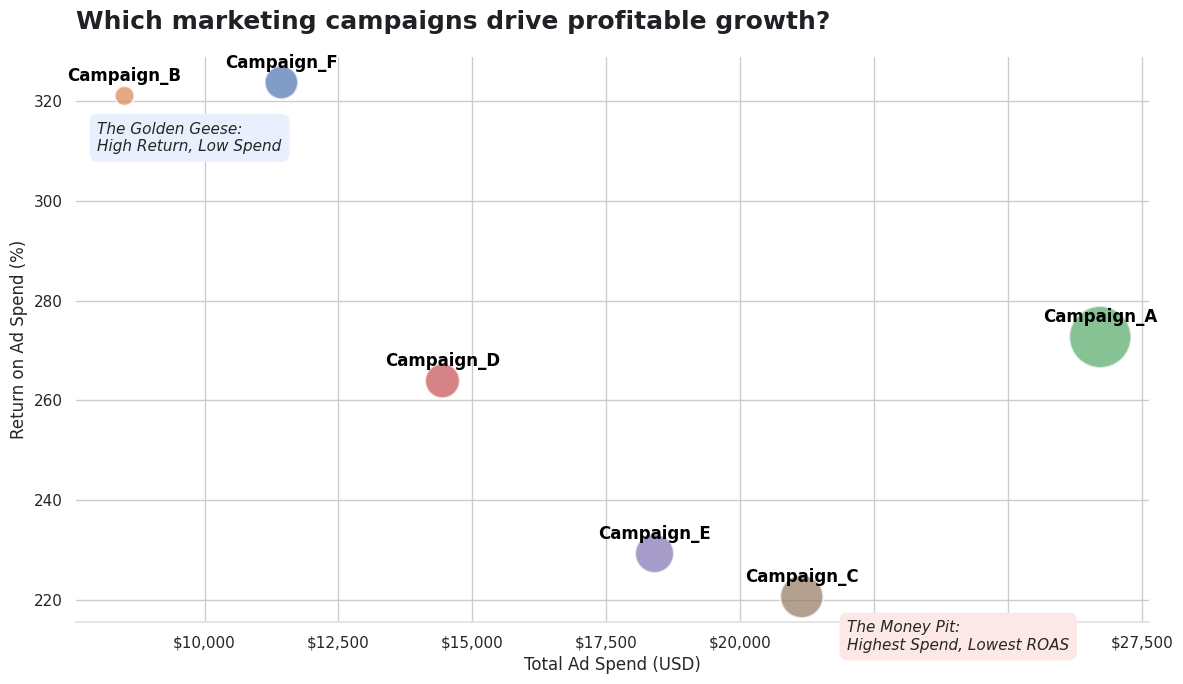

In [79]:
# --- CHART 3: CAMPAIGN EFFICIENCY ---
fig, ax = plt.subplots(figsize=(12, 7))

# Create the bubble chart
scatter = sns.scatterplot(
    data=roas_final,
    x='Total_Ad_Spend_USD',
    y='ROAS_%',
    size='Net_Revenue_USD',
    sizes=(200, 2000), # Min and max bubble sizes
    hue='campaign_name',
    alpha=0.7, # 70% opacity so overlapping bubbles are visible
    palette='deep',
    ax=ax,
    legend=False # Hide default legend to keep it clean
)

# Format the X-axis as Currency
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x:,.0f}'))

# Add Campaign Names next to the bubbles
for i in range(roas_final.shape[0]):
    ax.text(roas_final['Total_Ad_Spend_USD'].iloc[i],
            roas_final['ROAS_%'].iloc[i] + 3, # Offset slightly up
            roas_final['campaign_name'].iloc[i],
            horizontalalignment='center', size='medium', color='black', weight='semibold')

# Clean up axes and titles
ax.set_title("Which marketing campaigns drive profitable growth?", fontsize=18, fontweight='bold', color="#202124", pad=20, loc='left')
ax.set_ylabel("Return on Ad Spend (%)", fontsize=12)
ax.set_xlabel("Total Ad Spend (USD)", fontsize=12)

# Annotations
ax.text(8000, 310, "The Golden Geese:\nHigh Return, Low Spend", fontsize=11, style='italic', bbox=dict(facecolor='#E8F0FE', edgecolor='none', boxstyle='round,pad=0.5'))
ax.text(22000, 210, "The Money Pit:\nHighest Spend, Lowest ROAS", fontsize=11, style='italic', bbox=dict(facecolor='#FCE8E6', edgecolor='none', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

## 4. Retention & Quality (Pandas Heatmap Table)

In [81]:
# --- CHART 4: RETENTION HEATMAP TABLE ---
# We will use pandas .style to create a visual table right in the notebook

# Define the custom formatting dictionary
format_dict = {
    'Total_Paid_Users': '{:,}',
    'Avg_Billing_Cycles': '{:.2f}',
    'Churn_Rate_%': '{:.2f}%'
}

# Style the dataframe
styled_retention = (source_quality.style
    .background_gradient(subset=['Churn_Rate_%'], cmap='Reds', vmin=19.5, vmax=22.5) # Apply Heatmap to churn
    .background_gradient(subset=['Avg_Billing_Cycles'], cmap='Greens', vmin=0.9, vmax=1.1) # Apply Heatmap to LTV
    .format(format_dict)
    .set_caption("Retention & Churn by Acquisition Source")
    .set_table_styles([{
        'selector': 'caption',
        'props': [('color', '#202124'), ('font-size', '18px'), ('font-weight', 'bold'), ('text-align', 'left'), ('margin-bottom', '15px')]
    }, {
        'selector': 'th',
        'props': [('background-color', '#F8F9FA'), ('color', '#5F6368'), ('font-weight', 'bold')]
    }])
)

# Display the styled table in the notebook
display(styled_retention)

,Total_Paid_Users,Avg_Billing_Cycles,Churn_Rate_%
utm_source,,,
referral,362,1.06,20.72%
direct,433,0.98,21.25%
facebook,429,0.98,20.05%
google,398,0.97,22.11%
organic,401,0.95,19.70%
email,397,0.94,19.90%
